In [1]:
# ! pip install metapredict

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import metapredict

# 1. Properties of my sequences 
Calculated using ../scripts/calculate_properties.py

In [2]:
seq_df = pd.read_csv("../output/interpro_uniprot_evid_1_2_seq_props.csv")
seq_df

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,0.106472,69.311
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,0.109804,63.922
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,0.128668,67.494
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,0.162011,52.793
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,0.118033,68.033
...,...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,26,0.150000,15.667
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,14,0.144835,22.045
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,13,0.112245,82.313
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,-9,0.127660,36.474


In [7]:
sk_seqs_disord = seq_df[seq_df["percent_disorder"] > 25]
sk_seqs_disord

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,0.106472,69.311
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,0.109804,63.922
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,0.128668,67.494
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,0.162011,52.793
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,0.118033,68.033
...,...,...,...,...,...
137423,tr|W8BNV6|W8BNV6_CERCA Aminoacyl tRNA synthase...,MIIWSLLVIHNSLTMSLNRILAFGAGRIPISLLQRQTQQLKMPVLE...,12,0.132743,31.268
137429,tr|W8C4M4|W8C4M4_CERCA (Mediterranean fruit fl...,MYNGECGILIKDIKPGLKNINVIFIVLEIGTATVTKENREVRNFKV...,10,0.085185,58.889
137430,tr|W8C822|W8C822_CERCA (Mediterranean fruit fl...,MSQLNTPEKDAAGKPPTSRQQSTHSPNLTLQLPSPIITKRTRTAST...,0,0.111888,49.650
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,13,0.112245,82.313


# 2. Properties of Claire's seqs
Calculated using ../scripts/calculate_properties.py

In [4]:
cl_seqs = pd.read_csv("../output/cl_seqs_seq_props.csv")
cl_seqs

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,g003334.m1_alloascoidea_hylecoeti.final,MEQQPTQDNISNETHGSEEPPTKKSRSDNGTECETTDATPTINRNE...,-19,0.149310,50.439
1,g002909.m1_arxula_adeninivorans.final,MAEPDQISEGHESPGSSNKRQLHEVDHSDRSPRPEDTNGTKRPRTD...,-21,0.118138,58.115
2,g001599.m1_ashbya_aceri.final,MALGIPYLHEYDEDTLKQRLEAVLPGLPYATQLTLKSLPLLNDIST...,4,0.214429,25.651
3,g002398.m1_brettanomyces_anomalus.final,MADPDTSHKSPLLSENNLPHNNKKISDNVPTEEDGKKEAQTETPQI...,-39,0.153455,50.915
4,C2_04200W_A_candida_albicans.cgd,MSDQLEKDIEESIANLDYQQNQEHHETEQDKDKEHQDVEKQSSEEE...,-15,0.050000,100.000
...,...,...,...,...,...
110529,g005054.m1_saccharomyces_mikatae.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,-5,0.204983,92.752
110530,g005100.m1_saccharomyces_paradoxus.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.202489,80.882
110531,g002076.m1_saccharomyces_uvarum.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.204520,32.994
110532,g004724.m1_yHMPu5000034597_candida_stellimalic...,MNSNGSFKSIKGFNKVLNLIKYMLRFSKKKQNFARNSDNNNVTDYS...,3,0.219298,59.649


In [8]:
cl_seqs_disord = cl_seqs[cl_seqs["percent_disorder"] > 25]
cl_seqs_disord

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,g003334.m1_alloascoidea_hylecoeti.final,MEQQPTQDNISNETHGSEEPPTKKSRSDNGTECETTDATPTINRNE...,-19,0.149310,50.439
1,g002909.m1_arxula_adeninivorans.final,MAEPDQISEGHESPGSSNKRQLHEVDHSDRSPRPEDTNGTKRPRTD...,-21,0.118138,58.115
2,g001599.m1_ashbya_aceri.final,MALGIPYLHEYDEDTLKQRLEAVLPGLPYATQLTLKSLPLLNDIST...,4,0.214429,25.651
3,g002398.m1_brettanomyces_anomalus.final,MADPDTSHKSPLLSENNLPHNNKKISDNVPTEEDGKKEAQTETPQI...,-39,0.153455,50.915
4,C2_04200W_A_candida_albicans.cgd,MSDQLEKDIEESIANLDYQQNQEHHETEQDKDKEHQDVEKQSSEEE...,-15,0.050000,100.000
...,...,...,...,...,...
110529,g005054.m1_saccharomyces_mikatae.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,-5,0.204983,92.752
110530,g005100.m1_saccharomyces_paradoxus.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.202489,80.882
110531,g002076.m1_saccharomyces_uvarum.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.204520,32.994
110532,g004724.m1_yHMPu5000034597_candida_stellimalic...,MNSNGSFKSIKGFNKVLNLIKYMLRFSKKKQNFARNSDNNNVTDYS...,3,0.219298,59.649


In [9]:
len(sk_seqs_disord) + len(cl_seqs_disord)

188187

In [12]:
all_seqs_disord = pd.concat([sk_seqs_disord, cl_seqs_disord])
all_seqs_disord

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,0.106472,69.311
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,0.109804,63.922
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,0.128668,67.494
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,0.162011,52.793
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,0.118033,68.033
...,...,...,...,...,...
110529,g005054.m1_saccharomyces_mikatae.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,-5,0.204983,92.752
110530,g005100.m1_saccharomyces_paradoxus.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.202489,80.882
110531,g002076.m1_saccharomyces_uvarum.final,MMDMQVRKVRKPPACTQCRKRKIGCDRAKPICGNCVKYNKPDCFYP...,2,0.204520,32.994
110532,g004724.m1_yHMPu5000034597_candida_stellimalic...,MNSNGSFKSIKGFNKVLNLIKYMLRFSKKKQNFARNSDNNNVTDYS...,3,0.219298,59.649


In [ ]:
#Saving the disordered sequnces only
protfasta.write_fasta(dict(zip(all_seqs_disord["id"], all_seqs_disord["seq"])), "../output/SK_CL_disord_input.fasta")

# 3. Lambert TFs comparison

In [7]:
lambert_TFs = protfasta.read_fasta("../data/lambert_TFs_10-21-24_with_DBD_coords.fasta")
lambert_TFs = pd.DataFrame({"id" : lambert_TFs.keys(), "seq" : lambert_TFs.values() })
lambert_TFs

,id,seq
0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...
1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...
2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...
3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...
4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...
...,...,...
1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...
1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...
1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...
1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...


In [8]:
lambert_TFs["net charge"] = lambert_TFs["seq"].str.count('R') + lambert_TFs["seq"].str.count('K') - lambert_TFs["seq"].str.count('D') - lambert_TFs["seq"].str.count('E')
lambert_TFs["hydrophobics_prop"] = (lambert_TFs["seq"].str.count('W') + lambert_TFs["seq"].str.count('F') + lambert_TFs["seq"].str.count('Y') + lambert_TFs["seq"].str.count('L')) / lambert_TFs["seq"].str.len()
lambert_TFs

,id,seq,net charge,hydrophobics_prop
0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,1,0.134100
1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,16,0.132641
2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,32,0.157895
3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,-20,0.100000
4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,-35,0.177706
...,...,...,...,...
1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,-1,0.124298
1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,46,0.159664
1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,84,0.117794
1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,-6,0.126643


In [11]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Define function for joblib
def calc_percent_disorder(seq):
    return metapredict.percent_disorder(seq)  
  
# Use joblib for parallelization and tqdm for progress
lambert_TFs["percent_disorder"] = Parallel(
    n_jobs=-1  # Use all cores
)(
    delayed(calc_percent_disorder)(seq) 
    for seq in tqdm(lambert_TFs["seq"], desc="Calculating disorder")
)


Calculating disorder: 100%|██████████| 1613/1613 [00:12<00:00, 131.05it/s]


# 4. Plotting

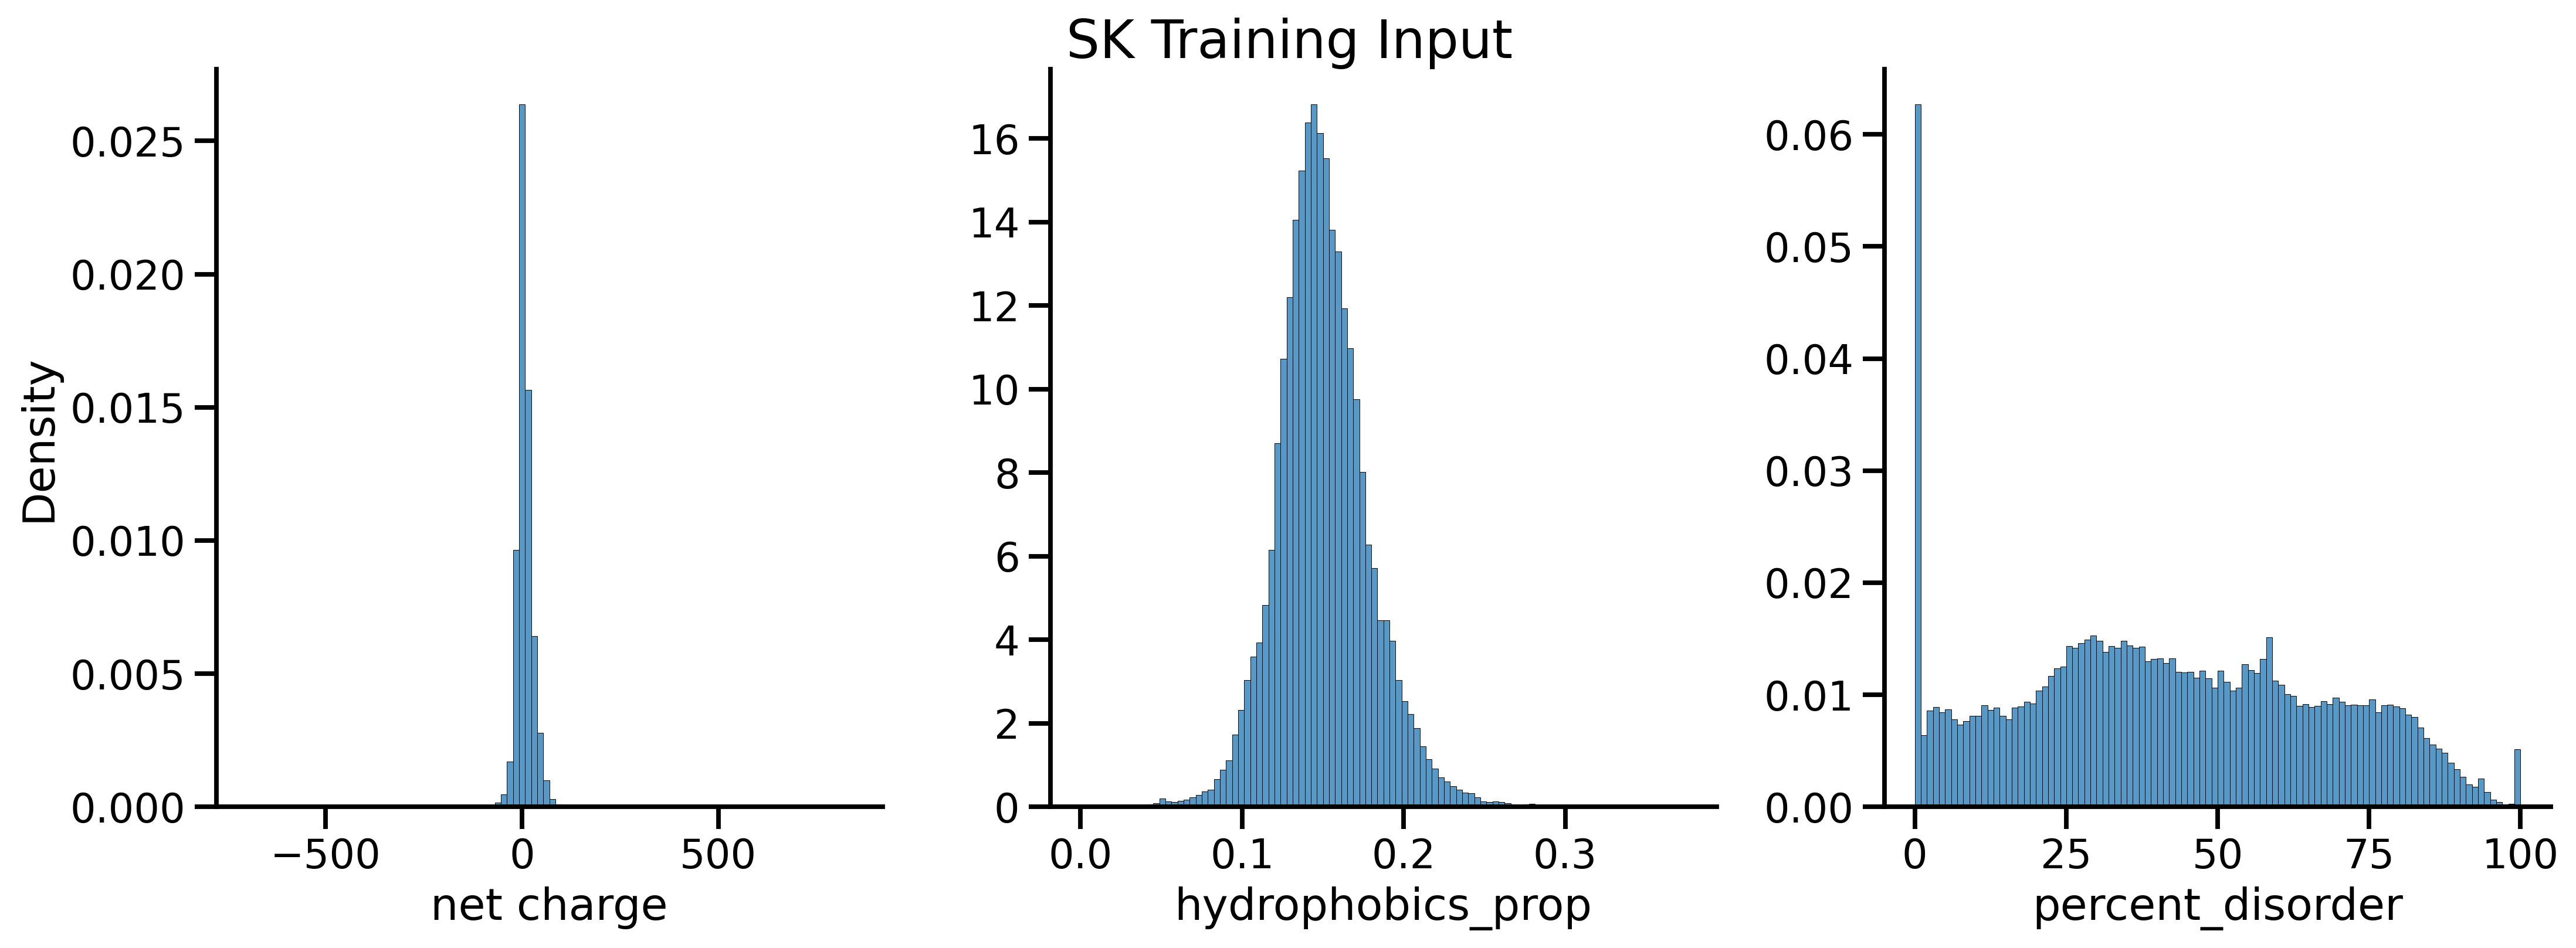

In [12]:
sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize = (15, 6), dpi = 300)

sns.histplot(seq_df["net charge"], ax = axs[0], stat = 'density', bins = 100)
sns.histplot(seq_df["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = 100)
sns.histplot(seq_df["percent_disorder"], ax = axs[2], stat = 'density', bins = 100)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
fig.suptitle("SK Training Input", y = 0.91)
plt.tight_layout()
plt.show()



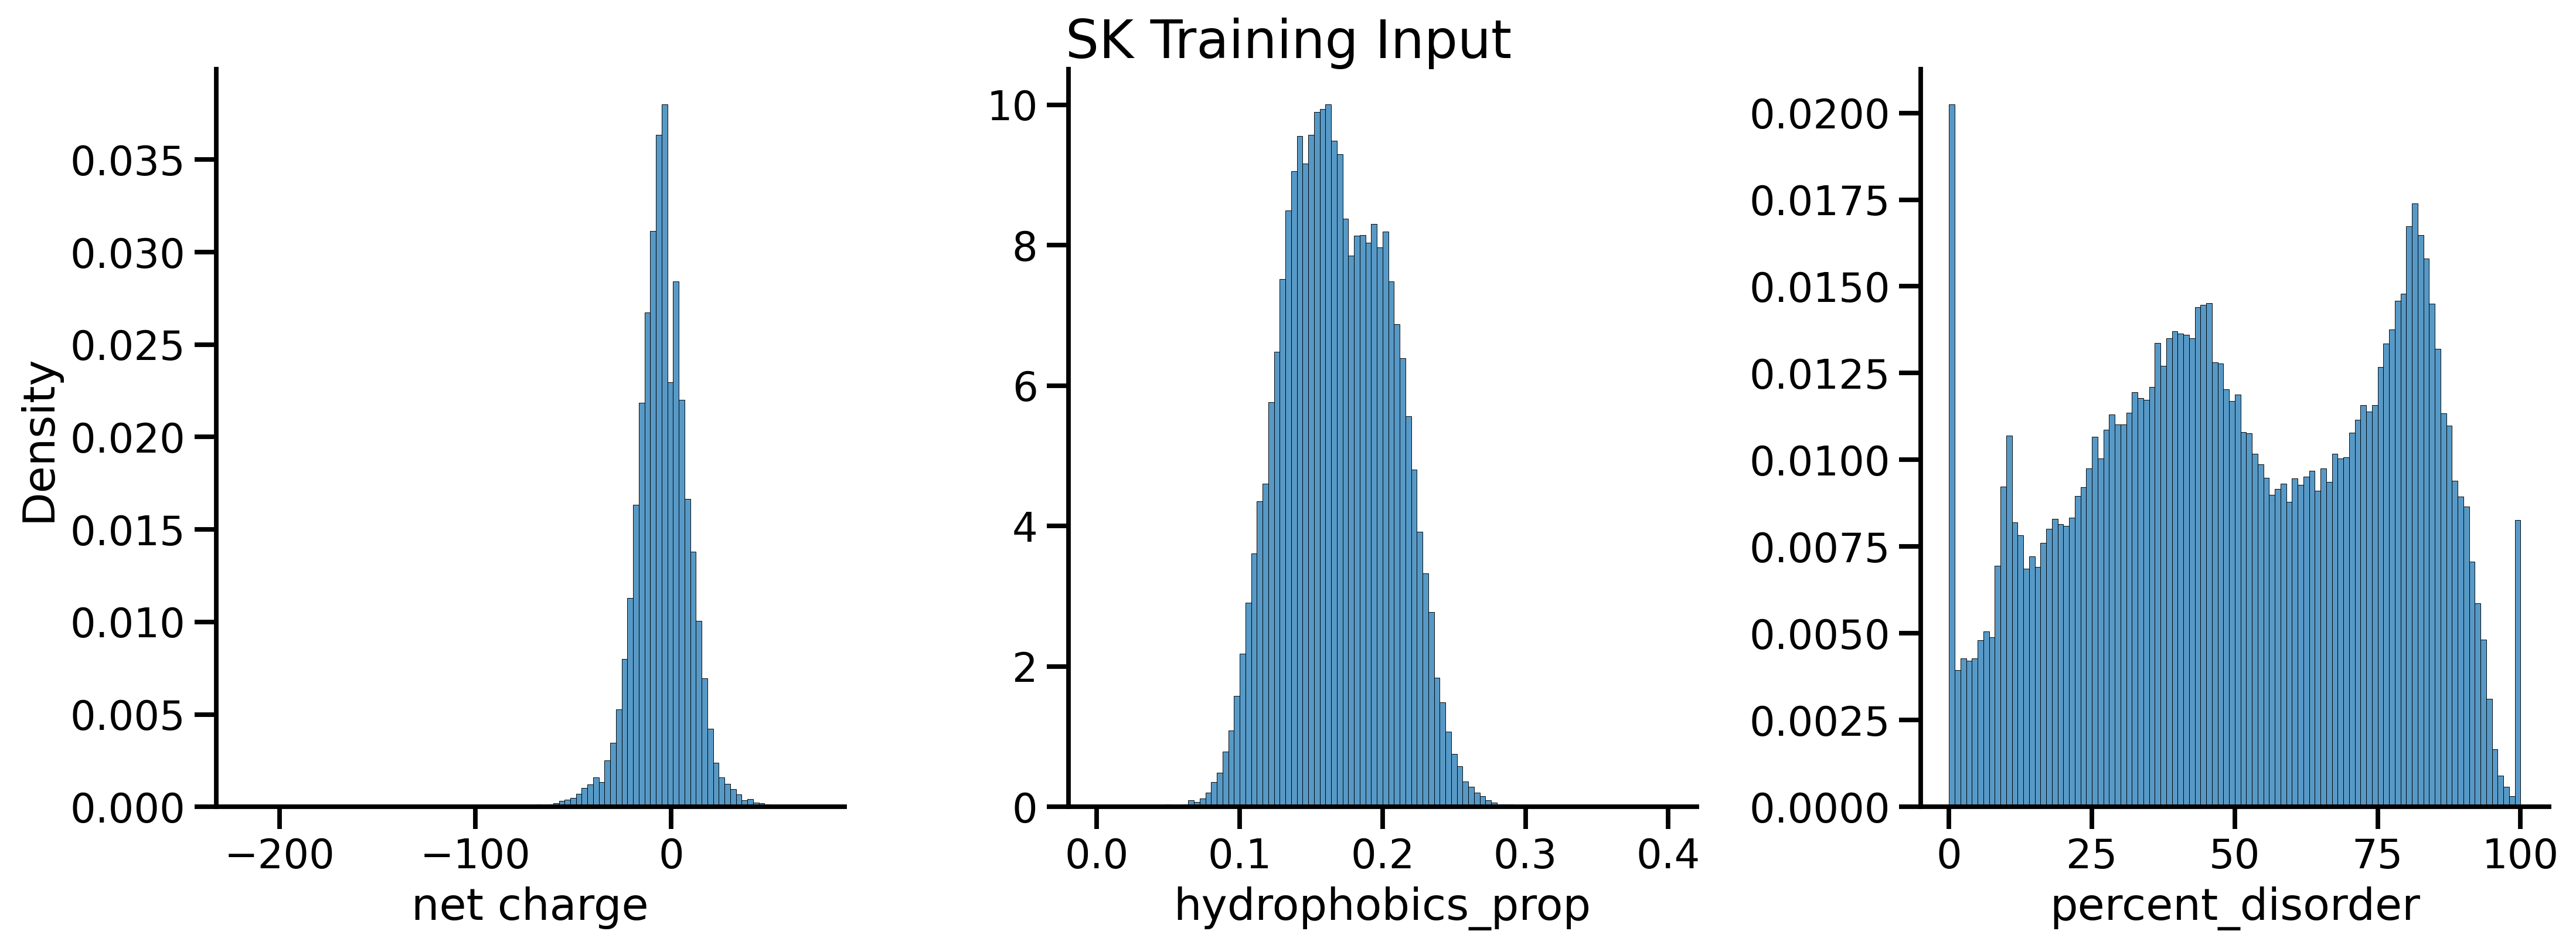

In [15]:
sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize = (15, 6), dpi = 300)

sns.histplot(cl_seqs["net charge"], ax = axs[0], stat = 'density', bins = 100)
sns.histplot(cl_seqs["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = 100)
sns.histplot(cl_seqs["percent_disorder"], ax = axs[2], stat = 'density', bins = 100)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
fig.suptitle("SK Training Input", y = 0.91)
plt.tight_layout()
plt.show()



In [38]:
SK_charge_outliers = seq_df[seq_df["net charge"].abs() > 250].copy(deep = True)
SK_charge_outliers["len"] = SK_charge_outliers["seq"].str.len()
SK_charge_outliers["abs net charge"] = seq_df["net charge"].abs()
SK_charge_outliers = SK_charge_outliers.sort_values(by="abs net charge", ascending = False)
print(SK_charge_outliers[["id", "net charge", "len"]].to_string(index=False))

                                                                                                                                    id  net charge   len
                 tr|A0A1I8GRW0|A0A1I8GRW0_9PLAT Gastrula zinc finger protein XlCGF26.1-like OS=Macrostomum lignano OX=282301 PE=1 SV=1         841  8417
                                           tr|M9PB30|M9PB30_DROME Dumpy, isoform Q OS=Drosophila melanogaster OX=7227 GN=dpy PE=1 SV=1        -702 22949
                    tr|A0A7R9GTI4|A0A7R9GTI4_TIMPO Zinc finger protein 865 OS=Timema poppense OX=170557 GN=TPSB3V08_LOCUS858 PE=1 SV=1         461  5118
                    tr|A0A7R9GQT3|A0A7R9GQT3_TIMCR Zinc finger protein 865 OS=Timema cristinae OX=61476 GN=TCEB3V08_LOCUS803 PE=1 SV=1         442  4864
                 tr|A0A7R9K0L7|A0A7R9K0L7_TIMGE Zinc finger protein 865 OS=Timema genevievae OX=629358 GN=TGEB3V08_LOCUS5775 PE=1 SV=1         401  4264
                        tr|A0A7R9FEC0|A0A7R9FEC0_9NEOP Zinc finger protein 865 OS=

In [53]:
sns.color_palette('viridis', 3)

[(0.229739, 0.322361, 0.545706),
 (0.127568, 0.566949, 0.550556),
 (0.369214, 0.788888, 0.382914)]

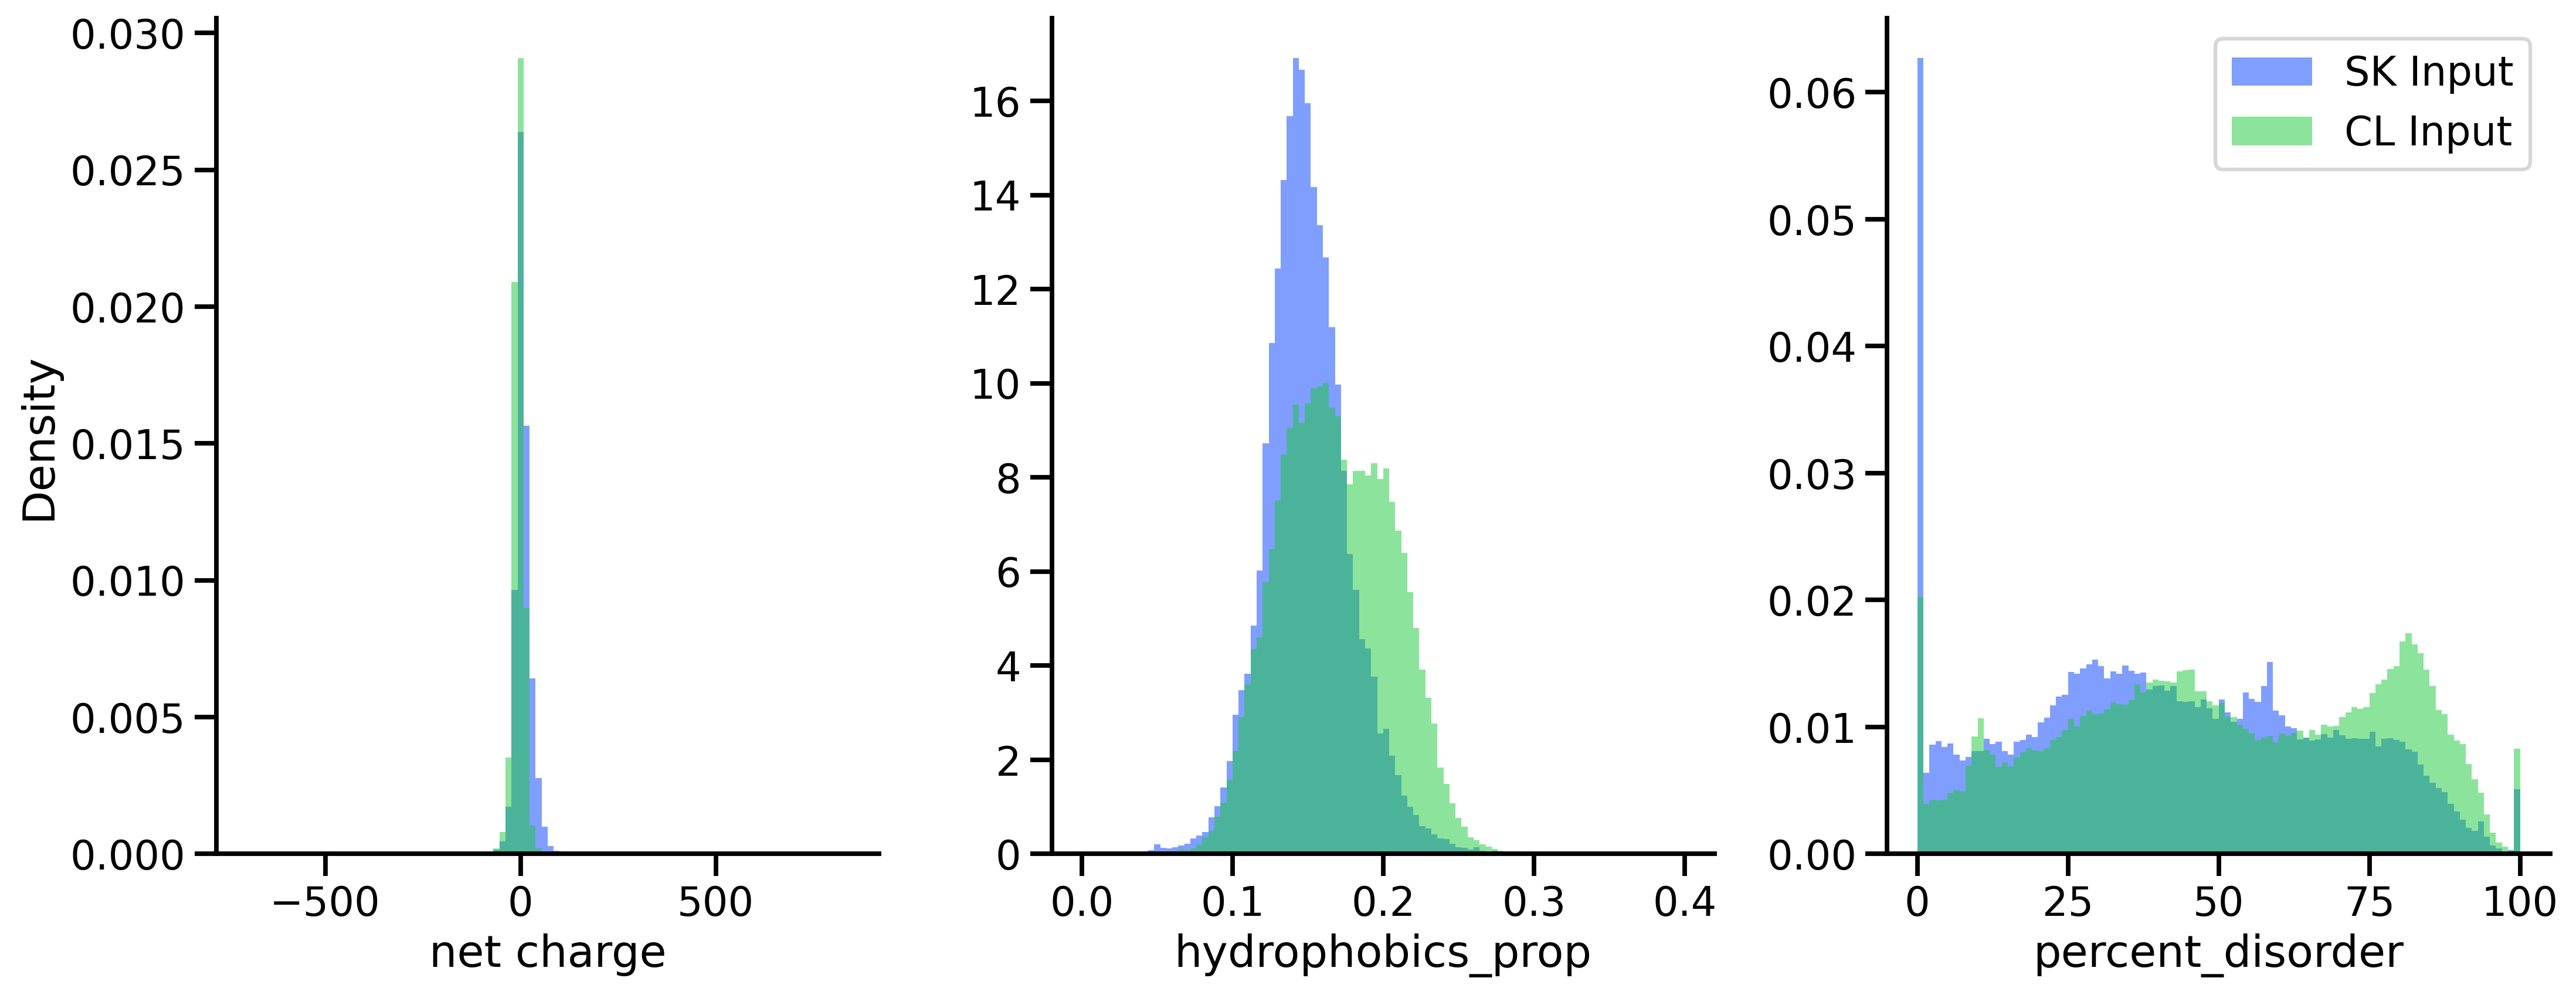

In [58]:
import numpy as np

sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=300)

# Ensure consistent bins for cl_seqs as well
cl_net_charge_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["net charge"], lambert_TFs["net charge"], cl_seqs["net charge"]]), bins=100
)
cl_hydrophobics_prop_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["hydrophobics_prop"], lambert_TFs["hydrophobics_prop"], cl_seqs["hydrophobics_prop"]]), bins=100
)
cl_percent_disorder_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["percent_disorder"], lambert_TFs["percent_disorder"], cl_seqs["percent_disorder"]]), bins=100
)

palette = sns.color_palette('bright', 3)

# Plot histograms with shared bins
sns.histplot(seq_df["net charge"], ax=axs[0], label="SK Input", stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
# sns.histplot(lambert_TFs["net charge"], ax=axs[0], label="Lambert TFs", stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["net charge"], ax = axs[0], stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

sns.histplot(seq_df["hydrophobics_prop"], ax=axs[1], label="SK Input", stat='density', bins=cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
# sns.histplot(lambert_TFs["hydrophobics_prop"], ax=axs[1], label="Lambert TFs", stat='density', bins=cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

sns.histplot(seq_df["percent_disorder"], ax=axs[2], label="SK Input", stat='density', bins=cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
# sns.histplot(lambert_TFs["percent_disorder"], ax=axs[2], label="Lambert TFs", stat='density', bins=cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["percent_disorder"], ax = axs[2], label = "CL Input", stat = 'density', bins = cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()


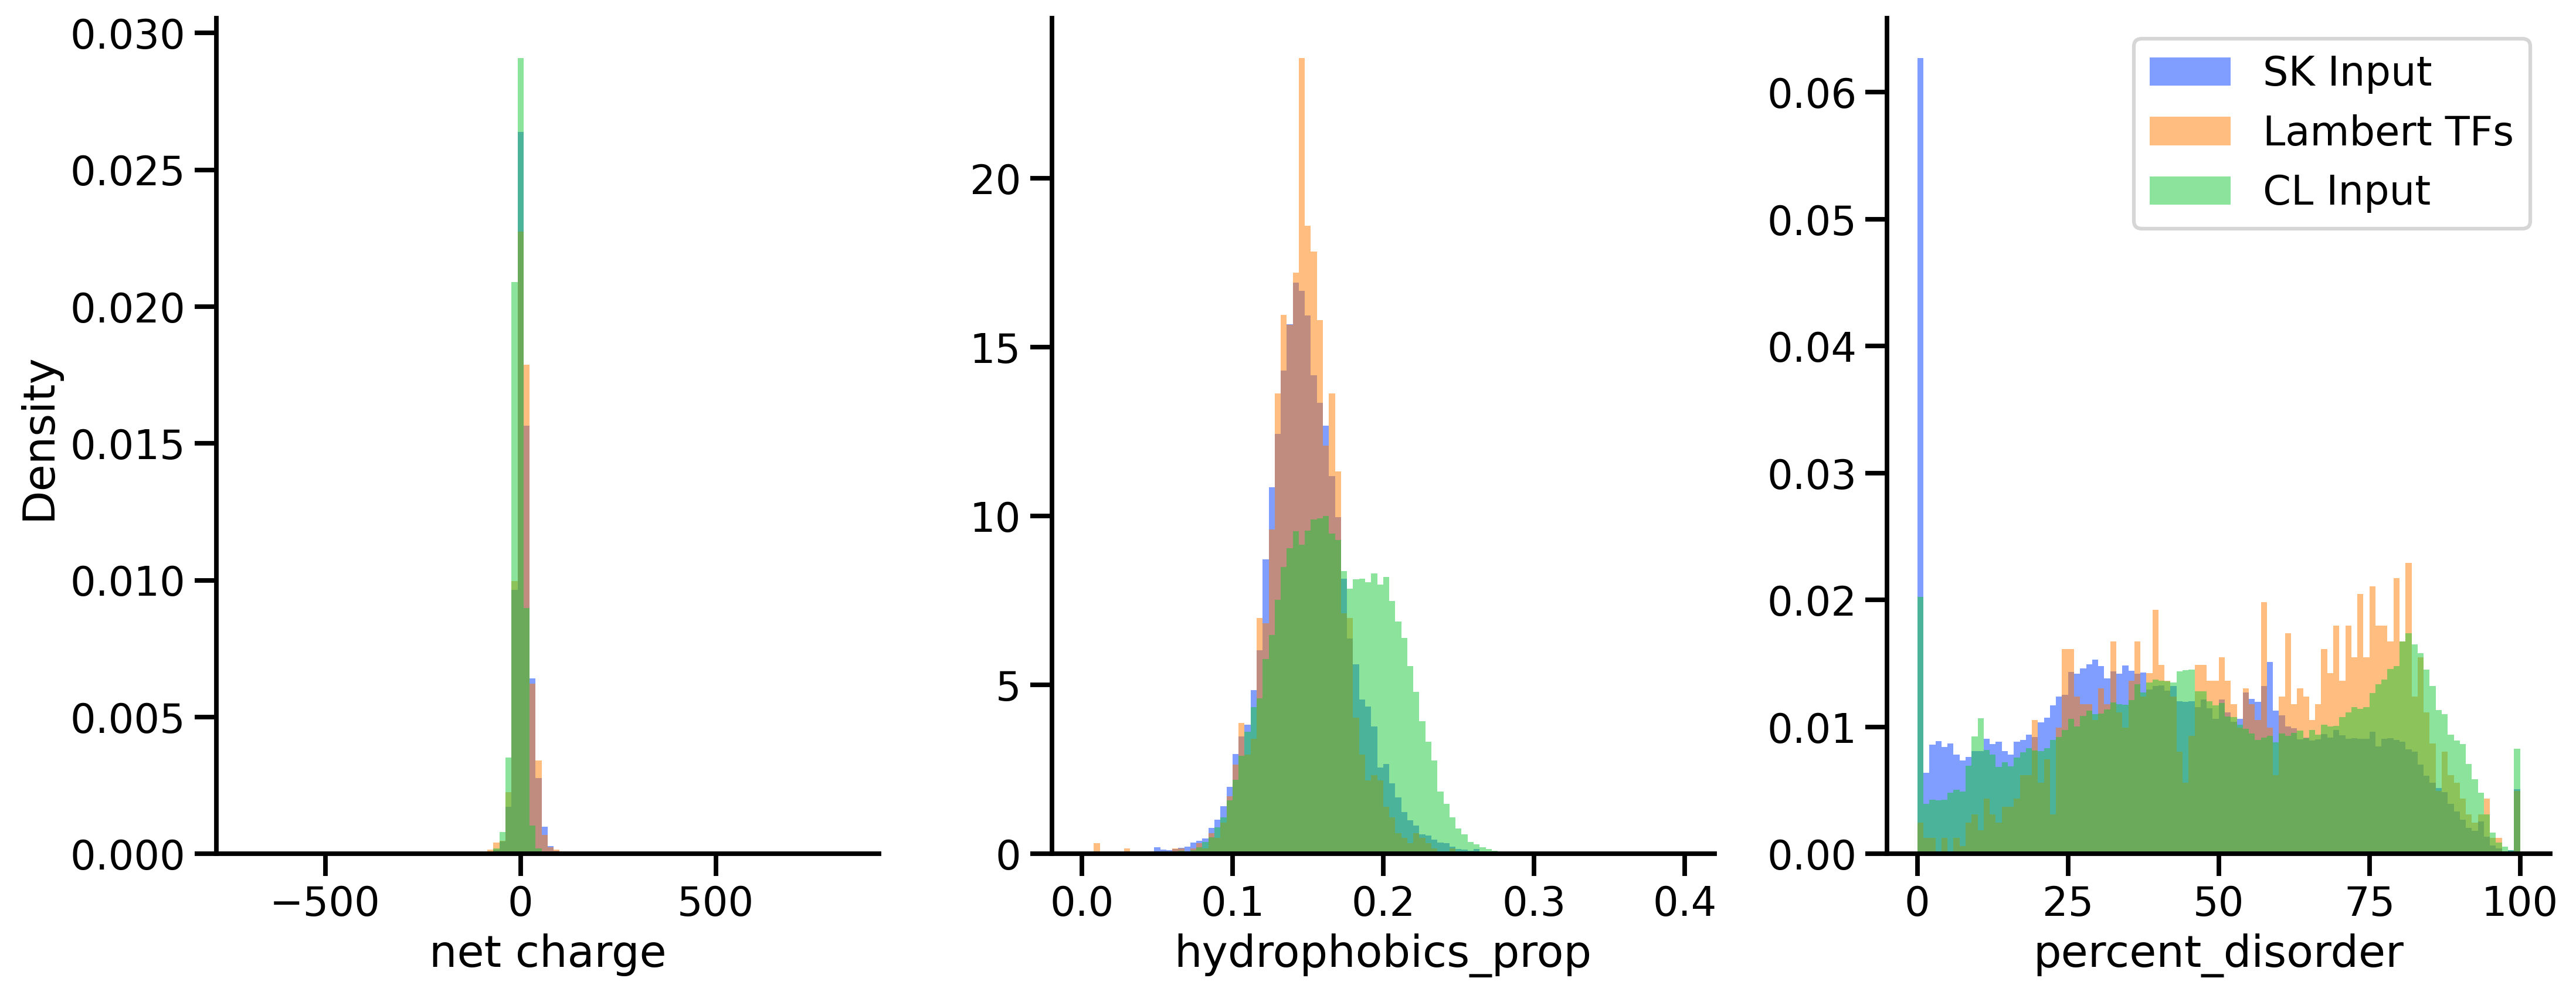

In [57]:
import numpy as np

sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=300)

# Ensure consistent bins for cl_seqs as well
cl_net_charge_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["net charge"], lambert_TFs["net charge"], cl_seqs["net charge"]]), bins=100
)
cl_hydrophobics_prop_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["hydrophobics_prop"], lambert_TFs["hydrophobics_prop"], cl_seqs["hydrophobics_prop"]]), bins=100
)
cl_percent_disorder_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["percent_disorder"], lambert_TFs["percent_disorder"], cl_seqs["percent_disorder"]]), bins=100
)

palette = sns.color_palette('bright', 3)

# Plot histograms with shared bins
sns.histplot(seq_df["net charge"], ax=axs[0], label="SK Input", stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
sns.histplot(lambert_TFs["net charge"], ax=axs[0], label="Lambert TFs", stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["net charge"], ax = axs[0], stat='density', bins=cl_net_charge_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

sns.histplot(seq_df["hydrophobics_prop"], ax=axs[1], label="SK Input", stat='density', bins=cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
sns.histplot(lambert_TFs["hydrophobics_prop"], ax=axs[1], label="Lambert TFs", stat='density', bins=cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = cl_hydrophobics_prop_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

sns.histplot(seq_df["percent_disorder"], ax=axs[2], label="SK Input", stat='density', bins=cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[0])
sns.histplot(lambert_TFs["percent_disorder"], ax=axs[2], label="Lambert TFs", stat='density', bins=cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[1])
sns.histplot(cl_seqs["percent_disorder"], ax = axs[2], label = "CL Input", stat = 'density', bins = cl_percent_disorder_bins, edgecolor = 'none', alpha = 0.5, color = palette[2])

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()


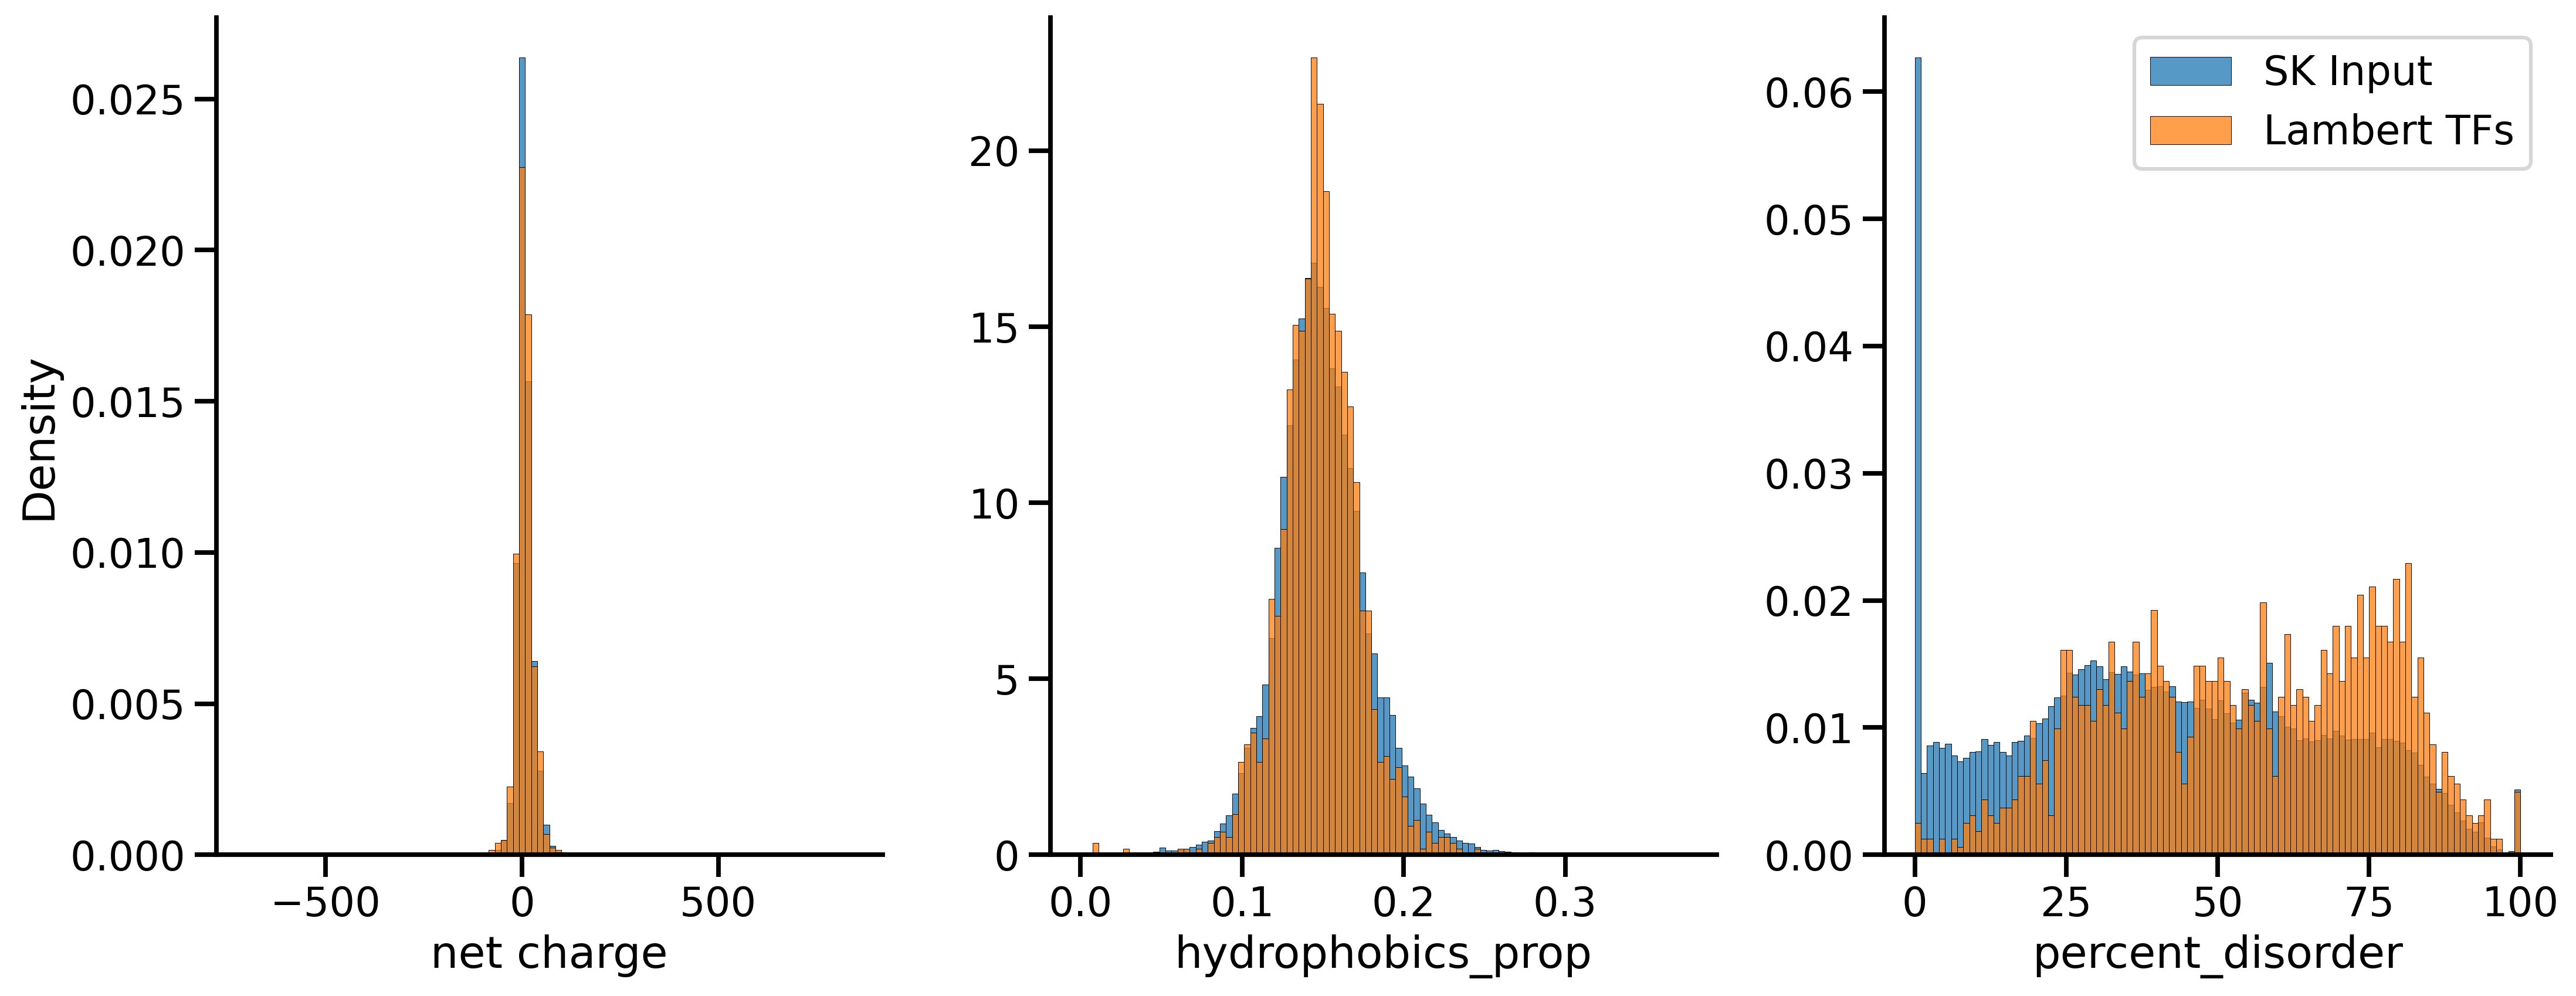

In [43]:
import numpy as np

sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=300)

# Calculate bin edges for each property
net_charge_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["net charge"], lambert_TFs["net charge"]]), bins=100
)
hydrophobics_prop_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["hydrophobics_prop"], lambert_TFs["hydrophobics_prop"]]), bins=100
)
percent_disorder_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["percent_disorder"], lambert_TFs["percent_disorder"]]), bins=100
)

# Plot histograms with shared bins
sns.histplot(seq_df["net charge"], ax=axs[0], label="SK Input", stat='density', bins=net_charge_bins)
sns.histplot(lambert_TFs["net charge"], ax=axs[0], label="Lambert TFs", stat='density', bins=net_charge_bins)

sns.histplot(seq_df["hydrophobics_prop"], ax=axs[1], label="SK Input", stat='density', bins=hydrophobics_prop_bins)
sns.histplot(lambert_TFs["hydrophobics_prop"], ax=axs[1], label="Lambert TFs", stat='density', bins=hydrophobics_prop_bins)

sns.histplot(seq_df["percent_disorder"], ax=axs[2], label="SK Input", stat='density', bins=percent_disorder_bins)
sns.histplot(lambert_TFs["percent_disorder"], ax=axs[2], label="Lambert TFs", stat='density', bins=percent_disorder_bins)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()


In [14]:
len(set(lambert_TFs["seq"]) & set(seq_df["seq"]))
# Almost all lambert TFs are in my training set

1452